In [16]:
from utils import * 
from dssp import DSSPFile
from fasta import FASTAFile
import subprocess
import json 
import Bio.PDB as PDB
from Bio.PDB import PDBParser, MMCIFParser, Structure, Model, Chain, Select
from scipy.spatial.distance import cdist
import numpy as np

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
genes_df = pd.read_csv('../data/genes.csv', index_col=0)
genes_df = genes_df[genes_df.cluster_id == 1].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_1.fa')

In [3]:
# First want to evaluate the quality of the ColabFold structures. 
COLABFOLD_DIR = '../data/genes/colabfold/'
COLABFOLD_PDB_FILE_NAME_PATTERN = r'*_relaxed_rank_001_alphafold2_ptm_model*.pdb'
COLABFOLD_SCORES_FILE_NAME_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'
COLABFOLD_PLDDTS = dict()

for path in glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_SCORES_FILE_NAME_PATTERN)):    
    if get_gene_id(path) not in genes_df.index.values: 
        continue 

    with open(path, 'r') as f:
        scores = json.load(f)
        plddts = np.array(scores['plddt'])
        COLABFOLD_PLDDTS[get_gene_id(path)] = plddts

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}
# fig, ax = plt.subplots(figsize=(10, 3.5))
# for gene_id, plddts in COLABFOLD_PLDDTS.items():
#     ax.plot(np.arange(len(plddts)), plddts, label=gene_id, color=palette[gene_id])
# ax.set_xlim(xmin=0, xmax=250)
# ax.set_ylabel('pLDDT')
# ax.set_xlabel('position')
# plt.show()

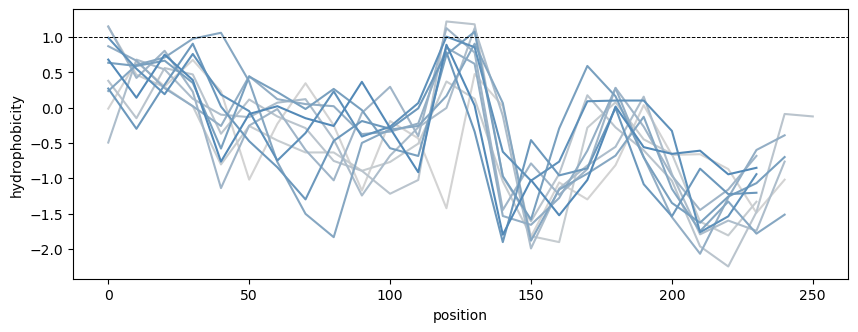

In [4]:
HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

window_size = 20
step_size = 10

cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

fig, ax = plt.subplots(figsize=(10, 3.5))

for row in genes_df.itertuples():
    window_starts = list(range(0, len(row.seq), step_size))[:-1]
    windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]

    hydrophobicity = [get_hydrophobicity(seq) for seq in windows]

    ax.plot(window_starts, hydrophobicity, label=row.Index, color=palette[row.Index])

ax.set_ylabel('hydrophobicity')
ax.set_xlabel('position')
ax.axhline(1, ls='--', color='black', lw=0.7)
plt.show()

In [191]:
genes_df.loc['orfm.bz_0.1_191'].seq

'LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLMDMILNNRMKVYSNMPLNFEQSGFNTLVQPYVSTSFFDNMPTGAIINWDEMPNDINARNFNSVKNKYVSVLSVDIAKKDDRLRGTFQFGDTVEKNLGDLCECIIIPEYVNNYSENTKEDNIQRVKEKDFLQHWIIIDKRNNDTHYELTFNLYPCIFFYNTKYKPIPLHVNHEDYIEKLKPQALSMFLSKNQNKINERFEHWNDGMKEIGKVMIR'

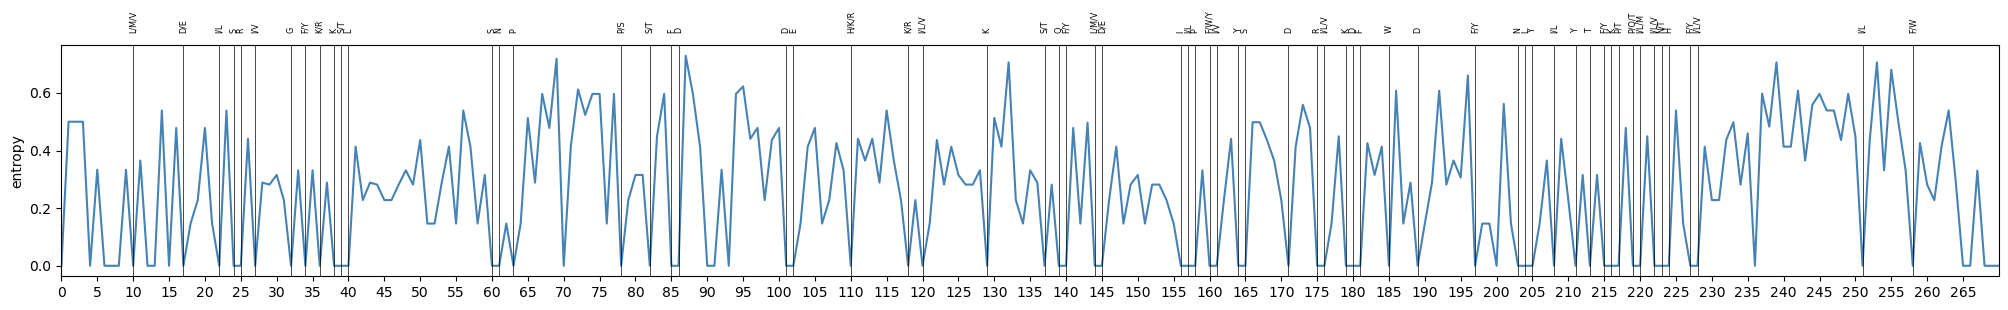

In [ ]:
MAX_ENTROPY = 0.1
msa = MSA(path='../data/genes/cluster_1.afa')

def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_arr(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSA.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSA.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))

# x_min, x_max = 240, 270
x_min, x_max = 0, 270
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
ax.plot(np.arange(len(entropy)), entropy, color='steelblue')

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSA.gap_symbol not in msa.to_arr().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_arr().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

ax.set_xticks(np.arange(x_min, x_max, 5))
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

In [117]:
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'accession', 'description', 'start','stop', 'e_value', 'status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
INTERPROSCAN_ATPASE_ACCESSIONS = ['G3DSA:3.40.50.300', 'SSF52540']

def load_atpase_annotations(path:str, gene_ids:list=None):
    df = pd.read_csv(path, sep='\t', header=None, names=INTERPROSCAN_FIELDS)
    if gene_ids is not None:
        df = df[df.gene_id.isin(gene_ids)].copy()
    df = df[df.accession.isin(INTERPROSCAN_ATPASE_ACCESSIONS)].copy() # P-loop containing nucleoside triphosphate hydrolase
    df = df.sort_values('e_value').drop_duplicates('gene_id')
    df['gene_id'] = df.gene_id.str.lower()
    print(f'load_atpase_annotations: Found {df.gene_id.nunique()} genes with ATPase annotations in {path}.')
    return df.drop(columns=['status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways', 'checksum'])

print('P-loop containing nucleoside triphosphate hydrolase domain indices:')
for row in load_atpase_annotations('../data/genes/interproscan/genes.tsv', gene_ids=genes_df.index.values).itertuples():
    start, stop = msa.map_idx_to_msa(row.start, row.gene_id), msa.map_idx_to_msa(row.stop, row.gene_id)
    print(f'{row.gene_id}\t{start}-{stop}')


P-loop containing nucleoside triphosphate hydrolase domain indices:
load_atpase_annotations: Found 5 genes with ATPase annotations in ../data/genes/interproscan/genes.tsv.
orfm.bz_10.1_15	25-190
orfm.bz_8.1_215	25-158
orfm.bz_9.1_34	24-214
orfm.bz_7.1_194	24-199
orfm.bz_1.1_155	24-200


In [118]:
WALKER_A_PATTERN = r'[A-Z][A-Z]{4}GK[ST]' # More general version, instead of r'[GAST][A-Z]{4}GK[ST]' 
WALKER_B_PATTERN = r'[AVLIMFYWC]{3,5}D[ED]' # More general version, instead of r'[AVLIMFYWC]{4}D[ED]' 


for row in msa.to_df().itertuples():
    wa_match = re.search(WALKER_A_PATTERN, row.seq)
    wb_match = re.search(WALKER_B_PATTERN, row.seq)

    info = f'{row.Index}'
    if wa_match is not None:
        info += f' Walker-A: {wa_match.group(0)} ({wa_match.start()} - {wa_match.end()})'
    if wb_match is not None:
        info += f' Walker-B: {wb_match.group(0)} ({wb_match.start()} - {wb_match.end()})'
    print(info)

WALKER_A_COORDS = (32, 40)
WALKER_B_COORDS = (96, 103)

for gene_id in genes_df.index:
    genes_df.loc[gene_id, 'walker_a_start'] = msa.map_idx_from_msa(WALKER_A_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_a_stop'] = msa.map_idx_from_msa(WALKER_A_COORDS[1], gene_id)
    genes_df.loc[gene_id, 'walker_b_start'] = msa.map_idx_from_msa(WALKER_B_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_b_stop'] = msa.map_idx_from_msa(WALKER_B_COORDS[1], gene_id)
# Based on the sructure, residues ~100-140 are pointed towards the inside of the toroid. 
# Residues 220-250 also look like they would be in contact with whatever is moving through the toroid. 
# ATPs look like they are binding by the W-A motif, which is good. 

orfm.bz_2.1_22 Walker-B: CIYIMDE (96 - 103)
orfm.bz_8.1_215 Walker-B: IIILDE (97 - 103)
orfm.bz_1.1_155 Walker-A: GEFGRGKT (32 - 40) Walker-B: LFIMDE (97 - 103)
orfm.bz_7.1_194 Walker-A: GEYGRGKS (32 - 40)
orfm.bz_9.1_34 Walker-A: GEYGRGKT (32 - 40)
orfm.bz_10.1_15 Walker-A: GRFGKGKS (32 - 40) Walker-B: LIIWDE (97 - 103)
orfm.bz_5.1_151 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_3.1_43 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_0.1_191 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_4.1_184 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_11.1_23 Walker-A: GRYSRGKS (32 - 40) Walker-B: IVWDE (98 - 103)


In [119]:
# Want to look for conserved arginine and/or lysine residues which could be involved in DNA binding (excluding the conserved R/K in the
# Walker-A motif, which is for ATP binding).

is_dna_binding = lambda aas : np.all(np.isin(aas, ['R', 'K']))

dna_binding_idxs = list()
for idx, aas in zip(conserved_idxs, conserved_aas):
    if not is_dna_binding(aas):
        continue
    if np.isin(idx, np.arange(WALKER_A_COORDS[0], WALKER_A_COORDS[1] + 1)):
        print(f'Skipping index {idx} because it is part of the Walker-A motif.')
        continue 
    if np.isin(idx, np.arange(WALKER_B_COORDS[0], WALKER_B_COORDS[1] + 1)):
        print(f'Skipping index {idx} because it is part of the Walker-B motif.')
        continue 
    dna_binding_idxs.append(idx)

print('Number of candidate DNA-binding residues:', len(dna_binding_idxs))

Skipping index 36 because it is part of the Walker-A motif.
Skipping index 38 because it is part of the Walker-A motif.
Number of candidate DNA-binding residues: 6


In [120]:
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
ALPHAFOLD_SUMMARY_FILE_PATTERN = r'(.+)_summary_confidences.json'

# ranking_score: Score used to rank models, which combined ipTM, pTM, disorder penalties, and clash penalties.
# iptm: Interface predicted TM-score, which is confidence in the relative placement of different chains (proteins, DNA, ligands).
# ptm: Predicted TM-score.
# chain_ptm: pTM calculated separately for each chain.
# chain_pair_iptm: Pairwise interface confidence between every pair of chains.
# fraction_disordered: Fraction predicted to be disordered.
# has_clash: Whether severe steric clashes were detected.

alphafold_summary_df = list()
for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*', '*')):
    match_ = re.search(ALPHAFOLD_SUMMARY_FILE_PATTERN, os.path.basename(path))
    if match_ is None:
        continue

    job_name = match_.group(1)

    row = {'job_name':job_name}
    row['n'] = int(re.search(r'(\d+)mer', job_name).group(1))
    ligands = job_name.split('-')[-1].split('_')
    row['dna'] = 'dna' in ligands
    row['mg_atp'] = ('mg' in ligands) and ('atp' in ligands)
    row['genome_id'] = get_genome_id(job_name)

    # The ordering of the output here should be the same as the ordering of the elements (proteins, ligands, etc.) in the input file. 
    # Because of how I constructed the input JSON, proteins are first n entries, followed by Mg, ATP, and DNA.
    with open(path, 'r') as f:
        summary = json.load(f)
        row.update({field:value for field, value in summary.items() if type(value) == float})
        # Get some statistics which should not include the ligands. 
        row['mean_protein_ptm'] = np.mean(summary['chain_ptm'][:row['n']])
        if row['n'] > 1:
            # Get only the protein-protein ipTM scores to make the comparison between Mg-ATP-bound complexes and complexes
            # with no ligands more valid (not affected by ipTM scores of the ligands).
            row['mean_protein_iptm'] = np.array(summary['chain_pair_iptm'])[np.triu_indices(row['n'], 1)].mean()
    alphafold_summary_df.append(row)
alphafold_summary_df = pd.DataFrame(alphafold_summary_df)

print('Mean pTM with bound Mg-ATP (protein chain only):', alphafold_summary_df[alphafold_summary_df.mg_atp].mean_protein_ptm.mean())
print('Mean ipTM with bound Mg-ATP (protein chain only):', alphafold_summary_df[alphafold_summary_df.mg_atp].mean_protein_iptm.mean())

print('Mean pTM with no bound Mg-ATP (protein chain only):', alphafold_summary_df[~alphafold_summary_df.mg_atp].mean_protein_ptm.mean())
print('Mean ipTM with no bound Mg-ATP (protein chain only):', alphafold_summary_df[~alphafold_summary_df.mg_atp].mean_protein_iptm.mean())

alphafold_summary_df = alphafold_summary_df[alphafold_summary_df.mg_atp].copy()


Mean pTM with bound Mg-ATP (protein chain only): 0.855413014069264
Mean ipTM with bound Mg-ATP (protein chain only): 0.38614842300556584
Mean pTM with no bound Mg-ATP (protein chain only): 0.8159104437229437
Mean ipTM with no bound Mg-ATP (protein chain only): 0.1914882498453927


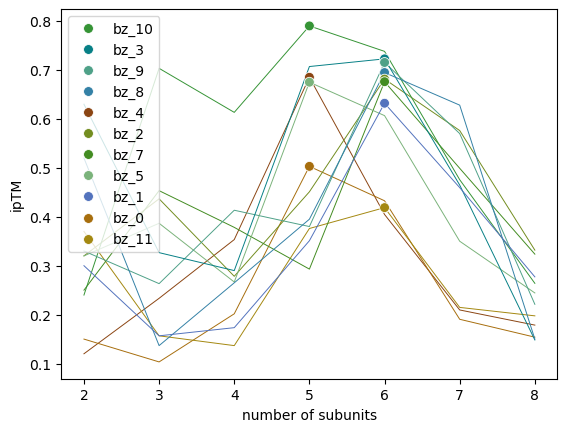

In [121]:

fig, ax = plt.subplots()

figure_df = alphafold_summary_df[alphafold_summary_df.n > 1].copy()

cmap = LinearSegmentedColormap.from_list('palette',  ['saddlebrown', 'darkgoldenrod', 'olivedrab', 'forestgreen', 'darkseagreen', 'teal', 'steelblue', 'slateblue'])
palette = {genome_id:cmap(i / figure_df.genome_id.nunique()) for i, genome_id in enumerate(figure_df.genome_id.unique())}

sns.lineplot(figure_df, x='n', y='mean_protein_iptm', hue='genome_id', lw=0.7, palette=palette, zorder=-1,legend=False)

figure_df = figure_df.sort_values('mean_protein_iptm', ascending=False).drop_duplicates('genome_id')
sns.scatterplot(figure_df, x='n', y='mean_protein_iptm', hue='genome_id', palette=palette, s=50)

ax.set_ylabel('ipTM')
ax.set_xlabel('number of subunits')
ax.legend().set_title('')
plt.show()

In [122]:
class Select(PDB.Select):

    def __init__(self, start:int, stop:int, chain_id:str='A'):
        self.chain_id = chain_id
        self.start = start
        self.stop = stop 

    def accept_chain(self, chain):
        return self.chain_id == chain.id 

    def accept_residue(self, residue):
        accept = (self.chain_id == residue.get_parent().id)

        i = residue.id[1] # residue.id is a 3-tuple, and the middle value is the residue number. 
        accept = accept and ((i > self.start) and (i <= self.stop)) # Account for the fact that the residue number is 1-indexed.
        return accept 


class PDBFile():

    def __init__(self):
        pass 

    @classmethod
    def from_file(cls, path, format:str=None):
        
        format = path.split('.')[-1] if (format is None) else format
        assert format in ['cif', 'pdb'], 'PDBFile.from_file: Format must be either pdb or cif.'
        
        parser = MMCIFParser(QUIET=True) if (format == 'cif') else PDBParser(QUIET=True)
        structure = parser.get_structure('protein', path)[0]

        obj = cls()
        obj.path = path  
        obj.structure = structure
        return obj 

    def subset(self, output_path:str, start:int=None, stop:int=None, chain_id:str='A'):
        assert start is not None, f'PDBFile.subset: The start and stop indices need to be numbers, got {type(start)}.'
        assert stop is not None, f'PDBFile.subset: The start and stop indices need to be numbers, got {type(start)}.'
        io = PDB.PDBIO()
        io.set_structure(self.structure)
        io.save(output_path,  Select(start, stop, chain_id=chain_id))



In [178]:
# (1) HK97 phage packaging terminase (TerL) is a pentamer, see https://pmc.ncbi.nlm.nih.gov/articles/PMC10370121/, https://academic.oup.com/nar/article/50/15/8719/6659863 (TERL_BPHK7)
# (2) Phi29 phage packaging ATPase (gp16) is also a pentamer, see https://www.nature.com/articles/s41467-019-10272-3, https://pmc.ncbi.nlm.nih.gov/articles/PMC8104870/ (PKG16_BPPH2)
# (3) P74-26 phage terminase (TerL) is a pentamer, see https://pmc.ncbi.nlm.nih.gov/articles/PMC4517215/ (A7XXR1_BP742)
# (4) Papillomavirus E1 helicase, involved in replication, is a hexamer, see https://pmc.ncbi.nlm.nih.gov/articles/PMC109901/ (VE1_HPV11). It binds to ssDNA, not dsDNA.

# Based on Thomsen et. al. 2008, it seems as though many RecA-like ATPase motors are hexamers. 
# There is potentially bias in AlphaFold structure prediction considering the abundance of hexameric ATPase assemblies. 
# The cluster_1 protein is clearly not a terminase, and seems to most closely correspond to pI phage assembly protein (Zot-like), and the pI quaternary structure has not been solved.

seqs = dict()
seqs['VE1_HPV11'] = 'MADDSGTENEGSGCTGWFMVEAIVEHTTGTQISEDEEEEVEDSGYDMVDFIDDRHITQNSVEAQALFNRQEADAHYATVQDLKRKYLGSPYVSPISNVANAVESEISPRLDAIKLTTQPKKVKRRLFETRELTDSGYGYSEVEAATQVEKHGDPENGGDGQERDTGRDIEGEGVEHREAEAVDDSTREHADTSGILELLKCKDIRSTLHGKFKDCFGLSFVDLIRPFKSDRTTCADWVVAGFGIHHSIADAFQKLIEPLSLYAHIQWLTNAWGMVLLVLIRFKVNKSRCTVARTLGTLLNIPENHMLIEPPKIQSGVRALYWFRTGISNASTVIGEAPEWITRQTVIEHSLADSQFKLTEMVQWAYDNDICEESEIAFEYAQRGDFDSNARAFLNSNMQAKYVKDCAIMCRHYKHAEMKKMSIKQWIKYRGTKVDSVGNWKPIVQFLRHQNIEFIPFLSKLKLWLHGTPKKNCIAIVGPPDTGKSCFCMSLIKFLGGTVISYVNSCSHFWLQPLTDAKVALLDDATQPCWTYMDTYMRNLLDGNPMSIDRKHRALTLIKCPPLLVTSNIDISKEEKYKYLHSRVTTFTFPNPFPFDRNGNAVYELSDANWKCFFERLSSSLDIEDSEDEEDGSNSQAFRCVPGSVVRTL'
seqs['PKG16_BPPH2'] = 'MDKSLFYNPQKMLSYDRILNFVIGARGIGKSYAMKVYPINRFIKYGEQFIYVRRYKPELAKVSNYFNDVAQEFPDHELVVKGRRFYIDGKLAGWAIPLSVWQSEKSNAYPNVSTIVFDEFIREKDNSNYIPNEVSALLNLMDTVFRNRERVRCICLSNAVSVVNPYFLFFNLVPDVNKRFNVYDDALIEIPDSLDFSSERRKTRFGRLIDGTEYGEMSLDNQFIGDSQVFIEKRSKDSKFVFSIVYNGFTLGVWVDVNQGLMYIDTAHDPSTKNVYTLTTDDLNENMMLITNYKNNYHLRKLASAFMNGYLRFDNQVIRNIAYELFRKMRIQ'
seqs['TERL_BPHK7'] = 'MTRGERVIAFIERFCIVPEGKLIGQPMRLDPFQKDFILAVYDNPAGTDMAILSIARKNGKTGLIAGILLAHLVGPEAVQNTQIVSGALSREQAAIVFNLAVKMVNLNPKLQEIVHITPSGKKLIGLPCNVEYKALSAEGKTTHGLSPILAILDETGQVRGPQDDFIDAITTAQGAHENPLLIVISTQAANDADLLSIWIDDAVKSKDPHIVCHVYEAPKDADISKRESWLAANPALGTFRSEKDMARQAEKAGRMPSFENTFRNLNLNQRVSTVSPFISRSVWELCGEMPINTPRKWYAGLDLSARNDLTALVIAGEADDGVWDVFPFFWTPQKTLEERTKTDRAPYDVWVREGLLRTTPGASVDYSFVVADIAEIIGDFDLTSMAFDRWRIDQFRKDADAIGLSLPLVEFGQGFKDMGPAVDTLESLMLNGRVRHGMHPVLTMCAVNAVVVKDAAGNRKLDKSKATGRIDGMVAMTMSVGAANGEVTEQGGDFDDFIFRPLSM'
seqs['A7XXR1_BP742'] = 'MKRLRPSDKFFELLGYKPHHVQLAIHRSTAKRRVACLGRQSGKSEAASVEAVFELFARPGSQGWIIAPTYDQAEIIFGRVVEKVERLAEVFPATEVQLQRRRLRLLVHHYDRPVNAPGAKRVATSEFRGKSADRPDNLRGATLDFVILDEAAMIPFSVWSEAIEPTLSVRDGWALIISTPKGLNWFYEFFLMGWRGGLKEGIPNSGINQTHPDFESFHAASWDVWPERREWYMERRLYIPDLEFRQEYGAEFVSHSNSVFSGLDMLILLPYERRGTRLVVEDYRPDHIYCIGADFGKNQDYSVFSVLDLDTGAIVCLERMNGATWSDQVARLKALSEDYGHAYVVADTWGVGDAIAEELDAQGINYTPLPVKSSSVKEQLISNLALLMEKGQVAVPNDKTILDELRNFRYYRTASGNQVMRAYGRGHDDIVMSLALAYSQYEGKDGYKFELAEERPSKLKHEESVMSLVEDDFTDLELANRAFSA'
seqs['VE1_BPV1'] = 'MANDKGSNWDSGLGCSYLLTEAECESDKENEEPGAGVELSVESDRYDSQDEDFVDNASVFQGNHLEVFQALEKKAGEEQILNLKRKVLGSSQNSSGSEASETPVKRRKSGAKRRLFAENEANRVLTPLQVQGEGEGRQELNEEQAISHLHLQLVKSKNATVFKLGLFKSLFLCSFHDITRLFKNDKTTNQQWVLAVFGLAEVFFEASFELLKKQCSFLQMQKRSHEGGTCAVYLICFNTAKSRETVRNLMANTLNVREECLMLQPAKIRGLSAALFWFKSSLSPATLKHGALPEWIRAQTTLNESLQTEKFDFGTMVQWAYDHKYAEESKIAYEYALAAGSDSNARAFLATNSQAKHVKDCATMVRHYLRAETQALSMPAYIKARCKLATGEGSWKSILTFFNYQNIELITFINALKLWLKGIPKKNCLAFIGPPNTGKSMLCNSLIHFLGGSVLSFANHKSHFWLASLADTRAALVDDATHACWRYFDTYLRNALDGYPVSIDRKHKAAVQIKAPPLLVTSNIDVQAEDRYLYLHSRVQTFRFEQPCTDESGEQPFNITDADWKSFFVRLWGRLDLIDEEEDSEEDGDSMRTFTCSARNTNAVD'
seqs = {gene_id.lower():seq for gene_id, seq in seqs.items()}

terl_bphk7_dna_binding_idxs = [89, 120, 121] # Putative, not confirmed. "The corresponding residues, R101 and K56 of P74-26 and phi29, respectively, have been shown to contribute to DNA binding."
a7xxr1_bp742_dna_binding_idxs = [99, 100, 101, 103, 127, 129] # Confirmed?


atpase_df = pd.DataFrame(index=list(seqs.keys()))
atpase_df['seq'] = atpase_df.index.map(seqs) # FASTAFile.from_df(atpase_df).write('../data/genes/atpase.faa')
atpase_df = atpase_df.merge(load_atpase_annotations('../data/genes/interproscan/atpase.tsv').set_index('gene_id'), left_index=True, right_index=True, how='left')
atpase_df['atpase_domain'] = [row.seq[row.start:row.stop] for row in atpase_df.itertuples()] # Extract the ATPase domain. 

ATPASE_DOMAIN_COORDS = (24, 215) # Relative to the Betazoid cluster_1 MSA.

for row in genes_df.itertuples():
    start, stop = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[0], row.Index), msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[1], row.Index)
    atpase_df.loc[row.Index, 'seq'] = row.seq 
    atpase_df.loc[row.Index, 'start'] = start 
    atpase_df.loc[row.Index, 'stop'] = stop
    atpase_df.loc[row.Index, 'atpase_domain'] = row.seq[start:stop]

for row in atpase_df[~atpase_df.index.str.startswith('orfm')].itertuples():
    print(row.Index, f'ATPase domain coordinates: {int(row.start)}-{int(row.stop)}')

FASTAFile.from_df(atpase_df).write('../data/genes/atpase.faa')
# FASTAFile.from_df(atpase_df.drop(columns='seq').rename(columns={'atpase_domain':'seq'})).write('../data/genes/atpase_domains.faa')
# First attempt was a sequence-based alignment, which failed, even after trimming the sequences to the ATPase domain. 


load_atpase_annotations: Found 10 genes with ATPase annotations in ../data/genes/interproscan/atpase.tsv.
ve1_hpv11 ATPase domain coordinates: 419-622
pkg16_bpph2 ATPase domain coordinates: 21-184
terl_bphk7 ATPase domain coordinates: 4-207
a7xxr1_bp742 ATPase domain coordinates: 4-196
ve1_bpv1 ATPase domain coordinates: 376-577


In [181]:
FOLDSEEK_INPUT_DIR = '../data/genes/foldseek/structures/atpase_domains'
FOLDSEEK_TMP_DIR = '../data/tmp'
FOLDSEEK_QUERY_DATABASE_PATH = '../data/genes/foldseek/db/atpase_domains/atpase_domains'
FOLDSEEK_OUTPUT_DATABASE_PATH = '../data/genes/foldseek/db/atpase_domains.out/atpase_domains.out'
FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'
FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/atpase_domains.tsv'

COLABFOLD_DIR = '../data/genes/colabfold'
COLABFOLD_FILE_NAME_PATTERN = r'|'.join([fr'{gene_id}_relaxed_rank_001_alphafold2_ptm_model_\d_seed_000.pdb' for gene_id in genes_df.index])

paths = {gene_id:f'../data/genes/alphafold/fold_{gene_id}_1mer_mg_atp/fold_{gene_id}_1mer_mg_atp_model_0.cif' for gene_id in seqs.keys()}
paths.update({get_gene_id(path):path for path in glob.glob('../data/genes/colabfold/*/*pdb') if (re.search(COLABFOLD_FILE_NAME_PATTERN, path) is not None)})

# For the structural alignment, want to subset the structure to match the ATPase domain. 
for gene_id, path in paths.items():
    output_path = os.path.join(FOLDSEEK_INPUT_DIR, f'{gene_id.lower()}_atpase_domain.pdb')
    if not os.path.exists(output_path):
        start, stop = atpase_df.loc[gene_id].start, atpase_df.loc[gene_id].stop
        PDBFile.from_file(path).subset(output_path, start=start, stop=stop)

    
print(f'foldseek createdb {FOLDSEEK_INPUT_DIR} {FOLDSEEK_QUERY_DATABASE_PATH}')
print(f'foldseek search {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_TMP_DIR} --alignment-type 1 -a')
print(f'foldseek convertalis {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_OUTPUT_PATH} --format-output {FOLDSEEK_FIELDS}')

foldseek_align_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, sep='\t', names=FOLDSEEK_FIELDS.replace('"', '').split(','))

# foldseek_align_df = foldseek_align_df.pivot(index='query', columns='target', values='alntmscore')

foldseek createdb ../data/genes/foldseek/structures/atpase_domains ../data/genes/foldseek/db/atpase_domains/atpase_domains
foldseek search ../data/genes/foldseek/db/atpase_domains/atpase_domains ../data/genes/foldseek/db/atpase_domains/atpase_domains ../data/genes/foldseek/db/atpase_domains.out/atpase_domains.out ../data/tmp --alignment-type 1 -a
foldseek convertalis ../data/genes/foldseek/db/atpase_domains/atpase_domains ../data/genes/foldseek/db/atpase_domains/atpase_domains ../data/genes/foldseek/db/atpase_domains.out/atpase_domains.out ../data/genes/foldseek/atpase_domains.tsv --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"


In [ ]:
# Commands to run in biotite. Actually, now mkdssp can be run locally! After I installed it according to the instructions on the GitHub. 
# for file_name in os.listdir('../data/genes/dssp/structures/cluster_1/'):
#     gene_id = get_gene_id(file_name)
#     cmd = f'mkdssp /home/philippar/dssp/structures/cluster_1/{file_name} /home/philippar/dssp/{gene_id}.dssp --output-format dssp'
#     # print(cmd)


print(f'genome ID\thelix start\thelix end\thelix length')
for path in glob.glob('../data/genes/dssp/*dssp'):
    if get_genome_id(path) == 'bz_2':
        # The bz_2 cluster_1 protein has a little extra strand at the end with helix predictions, which I want to ignore. 
        dssp = str(DSSPFile.from_file(path))[:-12] + ' ' # Add an extra character in case the helix continues to the end of the sequence.
    else: 
        dssp = str(DSSPFile.from_file(path)) + ' ' # Add an extra character in case the helix continues to the end of the sequence.
    dssp = np.array(list(dssp)) # Get the C-terminus as an array. 
    
    values = np.diff((dssp == 'H').astype(int))
    stop_idx = np.where(values == -1)[0][-1] # Get the last "helix close" spot. 
    start_idx = np.where(values == 1)[0][-1] # Get the last "helix open" spot. 
    print(f'{get_genome_id(path)}\t{start_idx}\t{stop_idx}\t{stop_idx - start_idx}')

genome ID	helix start	helix end	helix length
bz_7	222	256	34
bz_0	223	250	27
bz_2	216	250	34
bz_1	218	245	27
bz_11	224	240	16
bz_9	212	243	31
bz_8	217	249	32
bz_3	221	247	26
bz_5	217	244	27
bz_4	213	240	27
bz_10	216	236	20


In [176]:
for path in glob.glob('../data/genes/dssp/*dssp'):
    print(str(DSSPFile.from_file(path)))

 PEE   HHHHHHHHHT SEEEEE STTSSHHHHHHHHHHHHHHHHT  EEEESS B   TTGGGT EEEE  BGGGGGS  TTPEEEETTGGGTSBTTSTTSGGGHHHHHIIIIITTTT EEEEEES GGGB HHHHHH  EEEEEEES    SSHHHHHHHHHHHT  EEEEEEEETTTTEEEEEEEE GGGTTSB TT  PPPPB   HHHHHHHHHHS HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH  
 GGGGGS S HHHHHHHHHHHH SEEEE  STTSSHHHHHHHHHHHHHHHH    EEESS B  GGGT    PBP  BTHHHHTPPTT EEEETTGGGTS TT TTSGGGHHHHHHHHHHHHTT EEEEE S GGGS HHHHHH SEEEEEEES    SSHHHHHHHHHHHT  EEEEEEEEGGGTTEEEEEEEE GGGGGSB TT  PPPPB   HHHHHTS HHHHHHHHHHHHHHHHHHHHHHHHHHHTTTS    
  HHHHHHHHHT SEEEE SSTTSSHHHHHHHHHHHHHHHH   EEEESS B  TT TT EEEE  BSGGGSTTS   S EEEETTGGGTSBGGGTTSGGGHHHHHHHHHHHHTT EEEEE S GGGB HHHHHH  EEEEEEES    SSHHHHHHHHHHHT  EEEEEEEETTTTEEEEEEEE GGGGGGB TT  PPPPB   HHHHHHHHHH HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHT THHHHHTTS    
   HHHHHHHHHT SEEEEESSTTS HHHHHHHHHHHHHHHH   EEEESS B  GGGGGG EEEE  BGGGGTTPPTTEEEEETTTHHHH  S TTSTTTTHHHHHHHHTTTTT EEEEEES GGGS HHHHHH  EEEEEEES    SSHHHHHHHHHHHT  EEEEEEEETTTTEEEEEEEEE GGGGGGB TTPPPPPPB   HHHHHH

In [ ]:
RESIDUE_CHARGES = {'A':'.', 'C':'.', 'D':'-', 'E':'-', 'F': '.', 'G':'.', 'H':'.', 'I':'.', 'K':'+', 'L':'.', 'M':'.', 'N':'.', 'P':'.', 'Q':'.', 'R':'+', 'S':'.', 'T':'.', 'V':'.', 'W':'.', 'Y':'.'}

get_charge = lambda seq : ''.join([RESIDUE_CHARGES[aa] for aa in seq])
get_net_charge = lambda seq : get_charge(seq).count('+') - get_charge(seq).count('-')

for row in genes_df.itertuples():
    charges = get_charge(row.seq[-30:])
    print(f'{row.Index}\t', charges, f'\t({len(charges)}, {100 * charges.count('+') / len(charges):.2f}%, {get_net_charge(row.seq[-30:])})')

orfm.bz_0.1_191	 ....+...+..-+.-...-..+-..+...+ 	(30, 20.00%, 2)
orfm.bz_1.1_155	 ...+.-....-..-+.+...-...-.-+-. 	(30, 13.33%, -3)
orfm.bz_2.1_22	 -...-..+-......-....+-..+.+... 	(30, 13.33%, -1)
orfm.bz_3.1_43	 .......--...++++..-..+-..+...+ 	(30, 23.33%, 3)
orfm.bz_4.1_184	 ....+..+-..++.-..-....-..+...+ 	(30, 20.00%, 2)
orfm.bz_5.1_151	 ..--+++--...+.........-..+-..+ 	(30, 20.00%, 0)
orfm.bz_7.1_194	 ..-+.+-+.....-...-...+...+..-. 	(30, 16.67%, 0)
orfm.bz_8.1_215	 ..-..-..-+...-......-...-..-.. 	(30, 3.33%, -6)
orfm.bz_9.1_34	 -...-+...+..-.+........-..+++. 	(30, 20.00%, 2)
orfm.bz_10.1_15	 ....-..+..----.+.+.-...-.....- 	(30, 10.00%, -5)
orfm.bz_11.1_23	 ....+...-..++.-...-..+-..+...+ 	(30, 20.00%, 2)


In [ ]:
FOLDSEEK_INPUT_DIR = '../data/genes/foldseek/structures/cluster_1'
FOLDSEEK_TMP_DIR = '../data/tmp'
FOLDSEEK_QUERY_DATABASE_PATH = '../data/genes/foldseek/db/cluster_1/cluster_1'
FOLDSEEK_OUTPUT_DATABASE_PATH = '../data/genes/foldseek/db/cluster_1.out/cluster_1.out'
FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'
FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/cluster_1.tsv'

COLABFOLD_DIR = '../data/genes/colabfold'
COLABFOLD_FILE_NAME_PATTERN = '*_relaxed_rank_001_alphafold2_ptm_model*'


for path in glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_FILE_NAME_PATTERN)):
    gene_id = get_gene_id(path)
    if gene_id not in genes_df.index.values:
        continue
    output_path = os.path.join(FOLDSEEK_INPUT_DIR, f'{gene_id}.pdb')
    subprocess.run(f'cp {path} {output_path}', shell=True, check=True)
    
print(f'foldseek createdb {FOLDSEEK_INPUT_DIR} {FOLDSEEK_QUERY_DATABASE_PATH}')
print(f'foldseek search {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_TMP_DIR} --alignment-type 1 -a')
print(f'foldseek convertalis {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_OUTPUT_PATH} --format-output {FOLDSEEK_FIELDS}')

foldseek_align_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, sep='\t', names=FOLDSEEK_FIELDS.replace('"', '').split(','))

# foldseek_align_df = foldseek_align_df.pivot(index='query', columns='target', values='alntmscore')

foldseek createdb ../data/genes/foldseek/structures/cluster_1 ../data/genes/foldseek/db/cluster_1/cluster_1
foldseek search ../data/genes/foldseek/db/cluster_1/cluster_1 ../data/genes/foldseek/db/cluster_1/cluster_1 ../data/genes/foldseek/db/cluster_1.out/cluster_1.out ../data/tmp --alignment-type 1 -a
foldseek convertalis ../data/genes/foldseek/db/cluster_1/cluster_1 ../data/genes/foldseek/db/cluster_1/cluster_1 ../data/genes/foldseek/db/cluster_1.out/cluster_1.out ../data/genes/foldseek/cluster_1.tsv --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"


In [184]:
FOLDSEEK_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
FOLDSEEK_TARGET_DATABASE_PATTERN = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'

paths = {re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df[foldseek_search_df['query'].isin(genes_df.index.values)].copy()
foldseek_search_df['num_gaps'] = [max(row.qaln.count('-'), row.taln.count('-')) for row in foldseek_search_df.itertuples()]
foldseek_search_df = foldseek_search_df.drop(columns=['cigar', 'qtmscore', 'ttmscore', 'qheader', 'rmsd', 'fident', 'pident', 'nident', 'taxid'], errors='ignore')

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

Number of Foldseek hits for orfm.bz_0.1_191: 3994 	alphafold_uniprot (1218) alphafold_swissprot (949) pdb (921) bfvd (906)
Number of Foldseek hits for orfm.bz_1.1_155: 4030 	alphafold_uniprot (1217) alphafold_swissprot (975) pdb (956) bfvd (882)
Number of Foldseek hits for orfm.bz_10.1_15: 4038 	alphafold_uniprot (1218) alphafold_swissprot (954) pdb (951) bfvd (915)
Number of Foldseek hits for orfm.bz_11.1_23: 4052 	alphafold_uniprot (1217) alphafold_swissprot (982) pdb (933) bfvd (920)
Number of Foldseek hits for orfm.bz_2.1_22: 4059 	alphafold_uniprot (1215) alphafold_swissprot (992) pdb (953) bfvd (899)
Number of Foldseek hits for orfm.bz_3.1_43: 4078 	alphafold_uniprot (1215) alphafold_swissprot (987) pdb (956) bfvd (920)
Number of Foldseek hits for orfm.bz_4.1_184: 3948 	alphafold_uniprot (1215) alphafold_swissprot (959) pdb (908) bfvd (866)
Number of Foldseek hits for orfm.bz_5.1_151: 4057 	alphafold_uniprot (1217) alphafold_swissprot (990) pdb (953) bfvd (897)
Number of Foldseek

In [185]:
filters = dict()
filters['large_e_value'] = foldseek_search_df.evalue > 0.5
filters['too_many_gaps'] = (foldseek_search_df.gapopen > 15) | (foldseek_search_df.num_gaps > 50)
filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.6
# filters['short_target'] = (foldseek_search_df.tlen < 50) | (foldseek_search_df.num_gaps > 50)

foldseek_search_df = apply_filters(filters, foldseek_search_df).sort_values('bits')

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of filtered Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

apply_filters: 7073 entries removed by large_e_value.
apply_filters: 40321 entries removed by too_many_gaps.
apply_filters: 23423 entries removed by low_tm_score.
Number of filtered Foldseek hits for orfm.bz_0.1_191: 49 	bfvd (38) alphafold_uniprot (7) pdb (4)
Number of filtered Foldseek hits for orfm.bz_1.1_155: 213 	alphafold_uniprot (171) bfvd (33) pdb (9)
Number of filtered Foldseek hits for orfm.bz_10.1_15: 140 	alphafold_uniprot (106) bfvd (25) pdb (6) alphafold_swissprot (3)
Number of filtered Foldseek hits for orfm.bz_11.1_23: 69 	bfvd (52) pdb (9) alphafold_uniprot (8)
Number of filtered Foldseek hits for orfm.bz_2.1_22: 214 	alphafold_uniprot (180) bfvd (27) pdb (7)
Number of filtered Foldseek hits for orfm.bz_3.1_43: 205 	alphafold_swissprot (133) bfvd (50) alphafold_uniprot (15) pdb (7)
Number of filtered Foldseek hits for orfm.bz_4.1_184: 55 	bfvd (29) alphafold_uniprot (17) pdb (8) alphafold_swissprot (1)
Number of filtered Foldseek hits for orfm.bz_5.1_151: 210 	alphafol

In [186]:
foldseek_search_categories = dict()
foldseek_search_categories['RecA'] = foldseek_search_df.theader.str.contains('RecA|recA')
foldseek_search_categories['Zot'] = foldseek_search_df.theader.str.contains('Zot|Zona|occludens')
foldseek_search_categories['ATPase'] = foldseek_search_df.theader.str.contains('ATP|AAA')
foldseek_search_categories['uncharacterized'] = foldseek_search_df.theader.str.contains('uncharacterized', case=False) 
foldseek_search_categories['PhoH'] = foldseek_search_df.theader.str.contains('PhoH') 
foldseek_search_categories['terminase'] = foldseek_search_df.theader.str.contains('terminase') 
foldseek_search_categories['helicase'] = foldseek_search_df.theader.str.contains('helicase', case=False) 
foldseek_search_categories['recombinase'] = foldseek_search_df.theader.str.contains('recombinase', case=False) 
foldseek_search_categories['transposase'] = foldseek_search_df.theader.str.contains('transposase', case=False) 
foldseek_search_categories['RFC'] = foldseek_search_df.theader.str.contains('Replication factor C|Clamp Loader|RFC') 
foldseek_search_categories['MutS'] = foldseek_search_df.theader.str.contains('MutS|mismatch repair', case=False) 
foldseek_search_categories['thymidine kinase'] = foldseek_search_df.theader.str.contains('thymidine kinase', case=False) 
# items() output is [(key, value), (key, value), ...]. Then zip() takes the corresponding elements of each tuple, so end up with [(key, key, ...), (value, value, ..)]
foldseek_search_categories = list(zip(*list(foldseek_search_categories.items())))
foldseek_search_df['category'] = np.select(condlist=foldseek_search_categories[-1], choicelist=foldseek_search_categories[0], default='none')


In [192]:
reverse_complement('GAGAGAGAGTACACTTCCACCACTCAGACACTCTATAAATTCCCATCTGAAGTAA')

'TTACTTCAGATGGGAATTTATAGAGTGTCTGAGTGGTGGAAGTGTACTCTCTCTC'

In [ ]:
# Based on preliminary attempts with AlphaFold and the Foldseek hits, it seems likely that cluster_1 forms a homo-oligomer (or possibly with cluster_2, but
# one protein seems more likely). Still would like to try different configurations to get a rigorous assessment of the best configuration. 

ALPHAFOLD_DNA_SEQ = 'GAGAGAGAGTACACTTCCACCACTCAGACACTCTATAAATTCCCATCTGAAGTAA' # A random 55 bp section taken from the bz_0 genome. 
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input' # Directory name to match what is required on biotite.
ALPHAFOLD_BIOTITE_CMD = 'sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/{file_name} --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"'

def get_alphafold_input(gene_id, seq, n:int=1, ssdna:bool=False, dsdna:bool=False, atp:bool=False, mg:bool=False):
    '''Generate a JSON input file for the AlphaFold server. This is based on the job_request.json file which is included in the data downloaded
    from the online AlphaFold server.'''
    assert (ssdna ^ dsdna) or ((not dsdna) and (not ssdna)), f'get_alphafold_input: Only one of ssdna or dsdna can be True.'
    name = f'{get_genome_id(gene_id)}_cluster_1_{n}mer'
    ligands = list()

    input = dict()
    input['modelSeeds'] = ['42'] # Maybe worth using multiple seeds?
    input['dialect'] = 'alphafoldserver'
    input['version'] = 1
    input['sequences'] = list()
    input['sequences'].append({'proteinChain':{'sequence':seq, 'count':n}})
    if mg:
        ligands += ['mg']
        input['sequences'].append({'ion':{'ion':'MG', 'count':n}})
    if atp:
        ligands += ['atp']
        input['sequences'].append({'ligand':{'ligand':'CCD_ATP', 'count':n}})
    if ssdna:
        ligands += ['ssdna']
        input['sequences'].append({'dnaSequence':{'sequence':ALPHAFOLD_DNA_SEQ, 'count':1}})
    if dsdna:
        ligands += ['ssdna']
        input['sequences'].append({'dnaSequence':{'sequence':ALPHAFOLD_DNA_SEQ, 'count':1}})
        input['sequences'].append({'dnaSequence':{'sequence':reverse_complement(ALPHAFOLD_DNA_SEQ), 'count':1}})
    input['name'] = name + '-' + '_'.join(ligands) if (len(ligands) > 0) else name
    return input 


for row in genes_df.itertuples():
    input = list()
    for n in range(1, 9):
        input.append(get_alphafold_input(row.Index, row.seq, n=n))
        input.append(get_alphafold_input(row.Index, row.seq, n=n, mg=True, atp=True))
        # input.append(get_alphafold_input(row.Index, row.seq, n=n, mg=True, dna=True, atp=True))

    file_name = f'{row.genome_id}_cluster_1.json'
    with open(os.path.join(ALPHAFOLD_INPUT_DIR, file_name), 'w') as f:
        json.dump(input, f)
    print(ALPHAFOLD_BIOTITE_CMD.format(file_name=file_name))

# https://app.gitbook.com/o/-LzcB3BNVSNh_20MBLKi/s/-M-S5z_vnCqDzDHcfsmi/protein-folding
# run_alphafold3 --json_path=/root/af_input/af_input.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output


sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/bz_0_cluster_1.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/bz_1_cluster_1.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/bz_2_cluster_1.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/bz_3_cluster_1.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --json_path=/root/af_input/bz_4_cluster_1.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"
sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 

In [195]:
# Is there a conserved in-frame start codon?
for row in genes_df.itertuples():
    codons = np.array([row.nt_seq[i:i+3] for i in range(0, len(row.nt_seq), 3)])
    start_codon_idxs = np.where(np.isin(codons, ['ATG', 'GTG']))[0]
    print(f'{row.Index} start codon locations:', ' '.join(start_codon_idxs.astype(str)), '-', len(row.seq))

orfm.bz_0.1_191 start codon locations: 10 45 47 53 59 72 84 95 229 249 255 256 - 259
orfm.bz_1.1_155 start codon locations: 0 30 83 86 96 104 137 157 192 213 - 248
orfm.bz_2.1_22 start codon locations: 0 49 83 96 134 191 199 222 242 - 266
orfm.bz_3.1_43 start codon locations: 0 7 44 52 56 94 197 - 257
orfm.bz_4.1_184 start codon locations: 14 35 49 126 165 191 245 246 - 249
orfm.bz_5.1_151 start codon locations: 0 3 43 54 167 192 202 - 253
orfm.bz_7.1_194 start codon locations: 2 5 40 129 171 253 - 259
orfm.bz_8.1_215 start codon locations: 0 49 55 132 135 138 192 - 251
orfm.bz_9.1_34 start codon locations: 0 51 103 119 176 186 228 - 247
orfm.bz_10.1_15 start codon locations: 0 18 31 51 126 131 155 191 230 239 - 244
orfm.bz_11.1_23 start codon locations: 0 3 35 49 61 85 130 188 246 - 249


In [ ]:
# def dssp_add_pdb_header(path, output_dir='../data/genes/dssp/cluster_1/'):
#     # '''The ColabFold output PDB files contain ATOM entries for hydrogens, which is not compatible with the DSSP parser.'''
#     with open(path, 'r') as f:
#         lines = f.readlines()

#     # has_hydrogen = lambda line : line.strip().split()[-1] == 'H'
#     # lines = [line for line in lines if not has_hydrogen(line)]
#     lines = ['HEADER\tPROTEIN']
#     output_path = os.path.join(output_dir, os.path.basename(path))
#     with open(output_path, 'w') as f:
#         f.write('\n'.join(lines))
#     return output_path
    

In [ ]:
# def get_alphafold_input(gene_id, seq, n:int=1, dna:bool=False, atp:bool=False, mg:bool=False):
#     '''AlphaFold3 takes a JSON-style input, described here: https://github.com/google-deepmind/alphafold3/blob/main/docs/input.md'''
#     name = f'{get_genome_id(gene_id)}_cluster_1_{n}mer'
#     ligands = list()

#     input = dict()
#     input['modelSeeds'] = [1] # Maybe worth using multiple seeds?
#     input['dialect'] = 'alphafoldserver' # Biotite guidelines say to use 'alphafold3' here, but this produces an error.
#     input['version'] = 1
#     input['sequences'] = list()
#     input['sequences'].append({'protein':{'sequence':seq, 'id':[f'P{i}' for i in range(n)]}})
#     if mg:
#         ligands += ['mg']
#         input['sequences'].append({'ligand':{'ccdCodes':['MG'], 'id':[f'M{i}' for i in range(n)]}})
#     if atp:
#         ligands += ['atp']
#         input['sequences'].append({'ligand':{'id':[f'A{i}' for i in range(n)], 'ccdCodes':['ATP']}})
#     if dna:
#         ligands += ['dna']
#         input['sequences'].append({'dna':{'sequence':ALPHAFOLD_DNA_SEQ, 'id':['D1']}})
#         input['sequences'].append({'dna':{'sequence':reverse_complement(ALPHAFOLD_DNA_SEQ), 'id':['D2']}})
#     input['name'] = name + '-' + '_'.join(ligands) if (len(ligands) > 0) else name
#     return input 


In [ ]:
# ! muscle -align ../data/genes/atpase_domains.faa -output ../data/genes/atpase_domains.afa
# atpase_domains_msa = MSA('../data/genes/atpase_domains.afa')
# print(str(atpase_domains_msa))

# CARETTA_INPUT_DIR = '../data/genes/caretta/structures/atpase_domains/'
# CARETTA_OUTPUT_DIR = '../data/genes/caretta/atpase_domains.out/'
# cmd = f'\ncaretta-cli {CARETTA_INPUT_DIR} --no-pdb --matrix --output {CARETTA_OUTPUT_DIR} --features\n'
# print(cmd)

# paths = {gene_id:f'../data/genes/alphafold/fold_{gene_id}_1mer_mg_atp/fold_{gene_id}_1mer_mg_atp_model_0.cif' for gene_id in seqs.keys()}

# pattern = r'|'.join([fr'{gene_id}_relaxed_rank_001_alphafold2_ptm_model_\d_seed_000.pdb' for gene_id in genes_df.index])
# paths.update({get_gene_id(path):path for path in glob.glob('../data/genes/colabfold/*/*pdb') if (re.search(pattern, path) is not None)})

# # For the structural alignment, want to subset the structure to match the ATPase domain. 
# for gene_id, path in paths.items():
#     if gene_id[:2] == 'or':
#         output_path = os.path.join(CARETTA_INPUT_DIR, f'{gene_id.lower()}_atpase_domain.pdb')
#         start, stop = atpase_df.loc[gene_id].start, atpase_df.loc[gene_id].stop
#         PDBFile.from_file(path).subset(output_path, start=start, stop=stop)

# # caretta -i ./structures/atpase_domains -o ./
# atpase_domain_msa = MSA(f'{CARETTA_OUTPUT_DIR}result.fasta')